In [1]:
%load_ext autoreload
%autoreload 2

In [22]:

import numpy
import tifffile
import os
from matplotlib import pyplot
from skimage.transform import resize
from tiffwrapper import make_composite, ColorMapper

import sys
sys.path.insert(0, "..")

from figure import get_ground_truth_images, get_predicted_images, load_images, get_raw_images

methods = [
    "CARE2D",
    "N2V",
    "pix2pix",
    "UNet-RCAN",
    # "IMAGENET1K_V1",
    # "JUMP",
    # "HPA",
    # "SIM",
    "STED",
]
IMAGE_IDX = {
    "ov-lqhq-mt" : 1,
    "jmb-lqhq" : 44,
    "unet-rcan-tub" : 5,
    "kt-lqhq-vgat" : 59,
    "kt-lqhq-gephyrin" : 99,
    "kt-sr-vgat" : 172, # 11, 14
}
# dataset = "ov-lqhq-mt"
# dataset = "jmb-lqhq"
# dataset = "unet-rcan-tub"
# dataset = "kt-lqhq-vgat"
dataset = "kt-lqhq-gephyrin"
# dataset = "kt-sr-vgat"

In [8]:
def compute_residual_image(gt_image, predicted_image):
    """
    Computes the residual image between gt and predicted

    :param gt_image: A `numpy.ndarray` of the ground truth image
    :param predicted_image: A `numpy.ndarray` of the predicted image

    :returns : A `numpy.ndarray` of the residual image
    """
    return gt_image - predicted_image

def show_residual_image(residual_image, lut="Sci_bam", vmax=None):
    fig, ax = pyplot.subplots()
    if vmax is None:
        vmax = numpy.max(numpy.abs(residual_image))
    ax.annotate(f"MSE: {numpy.mean(residual_image**2):.4f}", xy=(0.01, 0.99), xycoords="axes fraction", color="black", fontsize=10, ha="left", va="top")
    residual_image_composite = make_composite(residual_image[numpy.newaxis], luts=[lut], ranges=[(-vmax, vmax)])
    ax.imshow(residual_image_composite)
    ax.axis("off")
    pyplot.show()    
    return residual_image_composite

from matplotlib.colors import ListedColormap
def show_colorbar(lut="Sci_bam", vmax=1.0):
    
    cmap = ColorMapper()[lut]
    cmap = ListedColormap(cmap.T/255.0)
    fig, ax = pyplot.subplots(figsize=(3, 3))
    gradient = numpy.linspace(-vmax, vmax, 256)
    gradient = numpy.outer(gradient, gradient)
    print(gradient.shape)
    # residual_image_composite = make_composite(gradient[numpy.newaxis], luts=[lut], ranges=[(-vmax, vmax)])
    im = ax.imshow(gradient, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_axis_off()
    cbar = pyplot.colorbar(im, ax=ax, orientation='vertical', fraction=0.1)
    fig.savefig(os.path.join("examples", f"{lut}-colorbar.pdf"), dpi=300, bbox_inches='tight')
    pyplot.show()
    # return residual_image_composite

(256, 256)


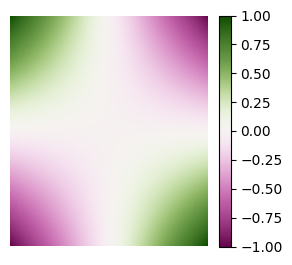

In [9]:
show_colorbar(lut="Sci_bam")

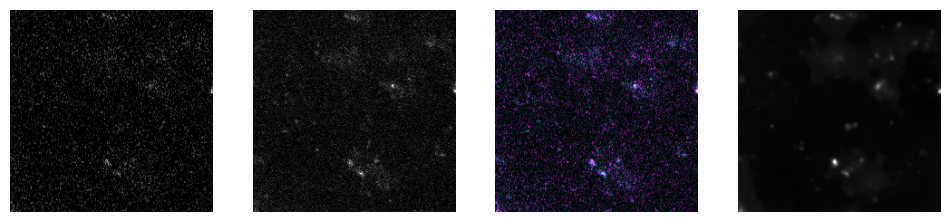

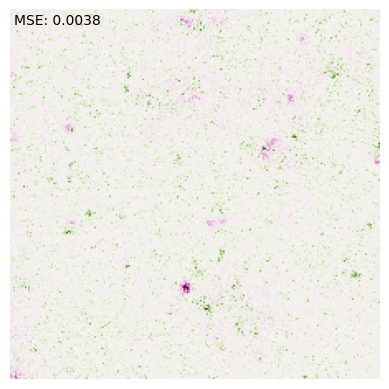

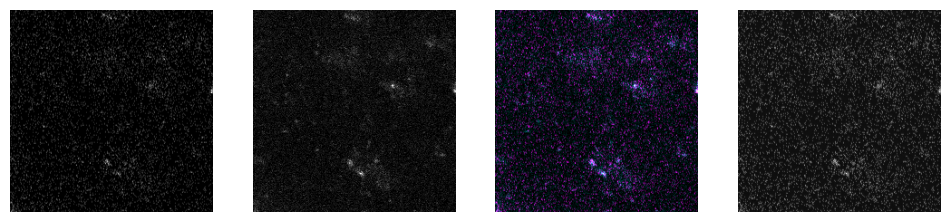

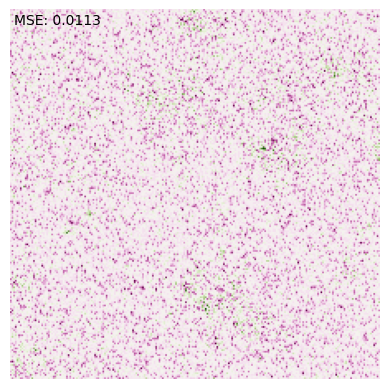

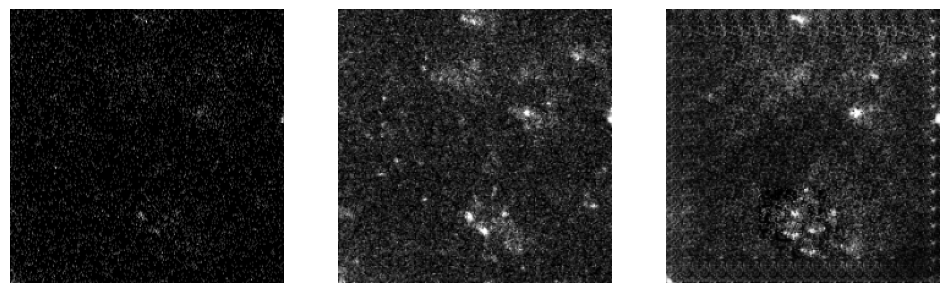

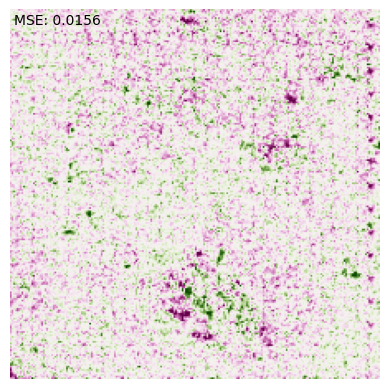

Processing method: UNet-RCAN


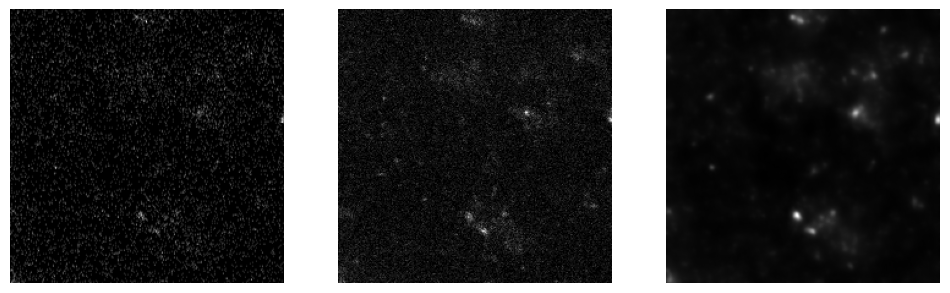

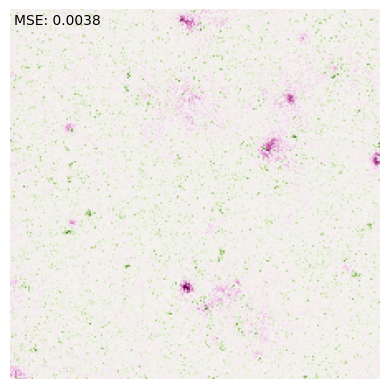

Processing method: STED


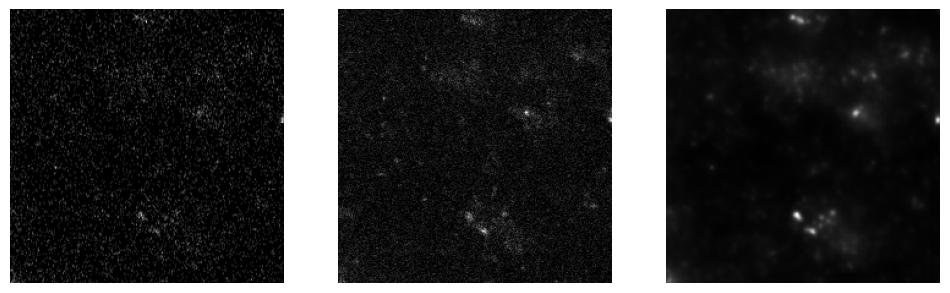

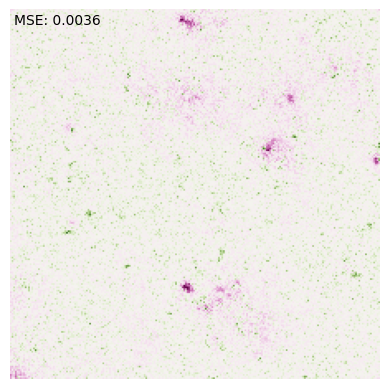

In [23]:
os.makedirs("examples", exist_ok=True)
idx = IMAGE_IDX[dataset]
# idx = 59
for i, method in enumerate(methods[:2]):

    if method == "N2V" and dataset == "kt-sr-vgat":
        continue

    if method in ["STED", "SIM", "HPA", "JUMP", "IMAGENET1K_V1"]:
        continue

    gt_images = get_ground_truth_images(dataset)
    raw_images = get_raw_images(dataset, gt_images)
    gt_images, predicted_images = get_predicted_images(method, dataset, gt_images)

    gt_images = load_images(gt_images)
    raw_images = load_images(raw_images)
    predicted_images = load_images(predicted_images)

    fig, axes = pyplot.subplots(1, 4, figsize=(12, 4))
    axes[0].imshow(raw_images[idx, 0, :224, :224], cmap="gray")
    axes[1].imshow(gt_images[idx, 0, :224, :224], cmap="gray")
    composite = make_composite(numpy.stack([
        raw_images[idx, 0, :224, :224],
        gt_images[idx, 0, :224, :224],
    ]), luts=["magenta", "cyan"], ranges=[(0, 0.5), (0, 1)])
    axes[2].imshow(composite)
    axes[3].imshow(predicted_images[idx, 0, :224, :224], cmap="gray")
    for ax in axes:
        ax.axis("off")
    pyplot.show()


    if i == 0:
        original_shape = gt_images.shape
        gt_image_ref = gt_images[idx, 0, :224, :224].copy()

        tifffile.imwrite(
            os.path.join("examples", f"{dataset}-raw.tif"),
            make_composite(raw_images[idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
        )
        tifffile.imwrite(
            os.path.join("examples", f"{dataset}-gt.tif"),
            make_composite(gt_images[idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
        )
    tifffile.imwrite(
        os.path.join("examples", f"{dataset}-{method}.tif"),
        make_composite(predicted_images[idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
    )

    residual_image = compute_residual_image(gt_images[idx, 0, :224, :224], predicted_images[idx, 0, :224, :224])
    residual_image_composite = show_residual_image(residual_image, vmax=0.5)

    tifffile.imwrite(
        os.path.join("examples", f"{dataset}-{method}-residual.tif"),
        residual_image_composite.astype(numpy.uint8),
    )

method = "pix2pix"
gt_images = get_ground_truth_images(dataset)
raw_images = get_raw_images(dataset, gt_images)
gt_images, predicted_images = get_predicted_images(method, dataset, gt_images)

gt_images = load_images(gt_images)
raw_images = load_images(raw_images)
predicted_images = load_images(predicted_images)

gt_images = resize(gt_images, original_shape, preserve_range=True, anti_aliasing=False).astype(gt_images.dtype)
predicted_images = resize(predicted_images, original_shape, preserve_range=True, anti_aliasing=False).astype(predicted_images.dtype)

fig, axes = pyplot.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(raw_images[idx, 0, :224, :224], cmap="gray")
axes[1].imshow(gt_images[idx, 0, :224, :224], cmap="gray")
axes[2].imshow(predicted_images[idx, 0, :224, :224], cmap="gray")
for ax in axes:
    ax.axis("off")
pyplot.show()

tifffile.imwrite(
        os.path.join("examples", f"{dataset}-{method}.tif"),
        make_composite(predicted_images[idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
    )

residual_image = compute_residual_image(gt_images[idx, 0, :224, :224], predicted_images[idx, 0, :224, :224])
residual_image_composite = show_residual_image(residual_image, vmax=0.5)
tifffile.imwrite(
    os.path.join("examples", f"{dataset}-{method}-residual.tif"),
    residual_image_composite.astype(numpy.uint8),
)

for method in methods[3:]:
    print(f"Processing method: {method}")

    gt_images = get_ground_truth_images(dataset)
    raw_images = get_raw_images(dataset, gt_images)
    gt_images, predicted_images = get_predicted_images(method, dataset, gt_images)

    gt_images = load_images(gt_images)
    raw_images = load_images(raw_images)
    predicted_images = load_images(predicted_images)

    min_idx = -1
    min_val = float("inf")
    for i, image in enumerate(gt_images):
        diff = numpy.sum(numpy.abs(image[0] - gt_image_ref))
        if diff < min_val:
            min_idx = i
            min_val = diff

    fig, axes = pyplot.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw_images[idx, 0, :224, :224], cmap="gray", vmin=0, vmax=1)
    axes[1].imshow(gt_images[min_idx, 0], cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(predicted_images[min_idx, 0], cmap="gray", vmin=0, vmax=1)
    for ax in axes:
        ax.axis("off")
    pyplot.show()
    
    tifffile.imwrite(
        os.path.join("examples", f"{dataset}-{method}.tif"),
        make_composite(predicted_images[min_idx, 0, :224, :224][numpy.newaxis], luts=["gray"], ranges=[(0, 1)]).astype(numpy.uint8),
    )

    residual_image = compute_residual_image(gt_images[min_idx, 0, :224, :224], predicted_images[min_idx, 0, :224, :224])
    residual_image_composite = show_residual_image(residual_image, vmax=0.5)
    tifffile.imwrite(
        os.path.join("examples", f"{dataset}-{method}-residual.tif"),
        residual_image_composite.astype(numpy.uint8),
    )

In [11]:
from collections import defaultdict
from tqdm.auto import trange

localcache = {}

scores_per_method = defaultdict(list)
for idx in trange(len(gt_images)):
    for i, method in enumerate(methods[:2]):

        if method == "N2V" and dataset == "kt-sr-vgat":
            continue

        if method in ["STED", "SIM", "HPA", "JUMP", "IMAGENET1K_V1"]:
            continue

        gt_images = get_ground_truth_images(dataset)
        raw_images = get_raw_images(dataset, gt_images)
        gt_images, predicted_images = get_predicted_images(method, dataset, gt_images)

        if (method, dataset) not in localcache:
            gt_images = load_images(gt_images)
            raw_images = load_images(raw_images)
            predicted_images = load_images(predicted_images)
            localcache[(method, dataset)] = (gt_images, raw_images, predicted_images)
        else:
            gt_images, raw_images, predicted_images = localcache[(method, dataset)]

        if i == 0:
            original_shape = gt_images.shape
            gt_image_ref = gt_images[idx, 0, :224, :224].copy()

        residual_image = compute_residual_image(gt_images[idx, 0, :224, :224], predicted_images[idx, 0, :224, :224])

        scores_per_method[method].append({
            "idx" : idx,
            "mse" : numpy.mean(residual_image**2)})

    method = "pix2pix"
    gt_images = get_ground_truth_images(dataset)
    raw_images = get_raw_images(dataset, gt_images)
    gt_images, predicted_images = get_predicted_images(method, dataset, gt_images)


    if (method, dataset) not in localcache:
        gt_images = load_images(gt_images)
        raw_images = load_images(raw_images)
        predicted_images = load_images(predicted_images)
        gt_images = resize(gt_images, original_shape, preserve_range=True, anti_aliasing=False).astype(gt_images.dtype)
        predicted_images = resize(predicted_images, original_shape, preserve_range=True, anti_aliasing=False).astype(predicted_images.dtype)
        localcache[(method, dataset)] = (gt_images, raw_images, predicted_images)
    else:
        gt_images, raw_images, predicted_images = localcache[(method, dataset)]

    residual_image = compute_residual_image(gt_images[idx, 0, :224, :224], predicted_images[idx, 0, :224, :224])

    scores_per_method[method].append({
        "idx" : idx,
        "mse" : numpy.mean(residual_image**2)})

    for method in methods[3:]:

        gt_images = get_ground_truth_images(dataset)
        raw_images = get_raw_images(dataset, gt_images)
        gt_images, predicted_images = get_predicted_images(method, dataset, gt_images)

        if (method, dataset) not in localcache:
            gt_images = load_images(gt_images)
            raw_images = load_images(raw_images)
            predicted_images = load_images(predicted_images)
            localcache[(method, dataset)] = (gt_images, raw_images, predicted_images)
        else:
            gt_images, raw_images, predicted_images = localcache[(method, dataset)]

        min_idx = -1
        min_val = float("inf")
        for i, image in enumerate(gt_images):
            diff = numpy.sum(numpy.abs(image[0] - gt_image_ref))
            if diff < min_val:
                min_idx = i
                min_val = diff

        residual_image = compute_residual_image(gt_images[min_idx, 0, :224, :224], predicted_images[min_idx, 0, :224, :224])
        scores_per_method[method].append({
            "idx" : min_idx,
            "mse" : numpy.mean(residual_image**2)})

  0%|          | 0/187 [00:00<?, ?it/s]

In [18]:
# # kt-sr-vgat
# target_sample = {
#     "CARE2D" : 0.0042,
#     "UNet-RCAN" : 0.0041,
#     "STED" : 0.0031,
# }
# # kt-lqhq-vgat
# target_sample = {
#     "CARE2D" : 0.0041,
#     "UNet-RCAN" : 0.0046,
#     "STED" : 0.0033,
# }
# kt-lqhq-gephyrin
target_sample = {
    "CARE2D" : 0.0039,
    "UNet-RCAN" : 0.0038,
    "STED" : 0.0030,
}

values = numpy.array(list(target_sample.values()))
to_sample_from_values = numpy.array([
    [item["mse"] for item in scores_per_method[method]]
    for method in target_sample.keys()
])

differences = numpy.sum(numpy.abs(to_sample_from_values - values[:, numpy.newaxis]), axis=0)
for arg in numpy.argsort(differences)[:10]:
    print(f"Overall difference: {differences[arg]:.6f}")
    print(f"Sample index: {arg}")
    for i, method in enumerate(target_sample.keys()):
        print(f"  Method: {method}, MSE: {to_sample_from_values[i, arg]:.6f}")
    print("")


Overall difference: 0.000762
Sample index: 99
  Method: CARE2D, MSE: 0.003806
  Method: UNet-RCAN, MSE: 0.003754
  Method: STED, MSE: 0.003622

Overall difference: 0.000838
Sample index: 61
  Method: CARE2D, MSE: 0.003781
  Method: UNet-RCAN, MSE: 0.003811
  Method: STED, MSE: 0.003707

Overall difference: 0.000945
Sample index: 91
  Method: CARE2D, MSE: 0.003684
  Method: UNet-RCAN, MSE: 0.003091
  Method: STED, MSE: 0.003020

Overall difference: 0.000998
Sample index: 176
  Method: CARE2D, MSE: 0.003207
  Method: UNet-RCAN, MSE: 0.003932
  Method: STED, MSE: 0.003173

Overall difference: 0.001013
Sample index: 133
  Method: CARE2D, MSE: 0.003980
  Method: UNet-RCAN, MSE: 0.003353
  Method: STED, MSE: 0.003487

Overall difference: 0.001111
Sample index: 54
  Method: CARE2D, MSE: 0.003565
  Method: UNet-RCAN, MSE: 0.003531
  Method: STED, MSE: 0.003507

Overall difference: 0.001145
Sample index: 51
  Method: CARE2D, MSE: 0.003951
  Method: UNet-RCAN, MSE: 0.003687
  Method: STED, MSE: 